# 🤖 DQN CartPole — Exploration Notebook

This notebook walks through the key components of the DQN project step by step.
It is meant as an interactive companion to the source code in `src/`.

**What we cover:**
1. Environment exploration — understanding CartPole
2. The DQN model — building and inspecting the neural network
3. The Replay Buffer — storing and sampling experiences
4. The DQN Agent — action selection and the learning step
5. Training curve — visualizing results after training
6. Watching the trained agent play

## 0. Setup

In [2]:
import sys
import os

# Allow importing from src/
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from model import DQN
from replay_buffer import ReplayBuffer
from agent import DQNAgent

print(f'PyTorch version : {torch.__version__}')
print(f'Gymnasium version: {gym.__version__}')
print(f'Device          : {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')

PyTorch version : 2.11.0+cpu
Gymnasium version: 1.2.3
Device          : cpu


---
## 1. Environment Exploration

Before building the agent, let's understand what CartPole-v1 looks like from the code's perspective.

CartPole is a classic control problem:
- A pole is attached to a cart that moves along a track
- The agent must push the cart left or right to keep the pole balanced
- The episode ends when the pole falls past 15° or the cart goes out of bounds
- Each step the pole stays up earns a reward of +1

In [3]:
env = gym.make('CartPole-v1')

print('=== CartPole-v1 Environment ===')
print(f'Observation space : {env.observation_space}')
print(f'  Shape           : {env.observation_space.shape}  ← 4 values per state')
print(f'  Low             : {env.observation_space.low}')
print(f'  High            : {env.observation_space.high}')
print()
print(f'Action space      : {env.action_space}')
print(f'  n               : {env.action_space.n}  ← 0 = push left, 1 = push right')

=== CartPole-v1 Environment ===
Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Shape           : (4,)  ← 4 values per state
  Low             : [-4.8               -inf -0.41887903        -inf]
  High            : [4.8               inf 0.41887903        inf]

Action space      : Discrete(2)
  n               : 2  ← 0 = push left, 1 = push right


In [4]:
# Reset the environment and inspect the initial state
state, info = env.reset(seed=42)
state = np.array(state, dtype=np.float32)

print('=== Initial State (after reset) ===')
labels = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Velocity']
for label, value in zip(labels, state):
    print(f'  {label:<25}: {value:.4f}')

=== Initial State (after reset) ===
  Cart Position            : 0.0274
  Cart Velocity            : -0.0061
  Pole Angle               : 0.0359
  Pole Angular Velocity    : 0.0197


In [5]:
# Run one random episode and collect rewards to understand the environment dynamics
state, _ = env.reset(seed=0)
state = np.array(state, dtype=np.float32)

rewards = []
step = 0

while True:
    action = env.action_space.sample()  # Random action
    next_state, reward, terminated, truncated, _ = env.step(action)
    rewards.append(float(reward))
    state = np.array(next_state, dtype=np.float32)
    step += 1
    if terminated or truncated:
        break

print(f'Random agent survived {step} steps (total reward: {sum(rewards):.0f})')
print('A trained DQN agent should consistently reach 475+ steps.')

Random agent survived 35 steps (total reward: 35)
A trained DQN agent should consistently reach 475+ steps.


---
## 2. The DQN Model

The neural network maps a state (4 values) to Q-values (one per action).

```
State (4) → Linear(4→128) → ReLU → Linear(128→128) → ReLU → Linear(128→2) → Q-values (2)
```

The agent picks the action with the **highest Q-value**.

In [6]:
# Instantiate the model
model = DQN(state_size=4, action_size=2, hidden_size=128)
print(model)
print()

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

DQN(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total trainable parameters: 17,410


In [7]:
# Run a forward pass with a dummy state
dummy_state = torch.tensor([[0.02, -0.01, 0.03, 0.05]], dtype=torch.float32)  # shape: (1, 4)

with torch.no_grad():
    q_values = model(dummy_state)

print(f'Input  shape : {dummy_state.shape}  ← (batch_size, state_size)')
print(f'Output shape : {q_values.shape}     ← (batch_size, action_size)')
print()
print(f'Q(push left)  = {q_values[0][0].item():.4f}')
print(f'Q(push right) = {q_values[0][1].item():.4f}')
print()
chosen = q_values.argmax(dim=1).item()
print(f'Chosen action : {chosen} ({"push left" if chosen == 0 else "push right"})')

Input  shape : torch.Size([1, 4])  ← (batch_size, state_size)
Output shape : torch.Size([1, 2])     ← (batch_size, action_size)

Q(push left)  = -0.1488
Q(push right) = 0.0033

Chosen action : 1 (push right)


### Understanding `.gather()` — picking the right Q-value

During training, the network outputs Q-values for **all** actions, but we only need the Q-value of the action that was **actually taken**. `.gather()` does exactly this.

In [8]:
# Example: batch of 3 states, 2 possible actions each
q_values_batch = torch.tensor([
    [0.2, 0.8],   # state 1 → Q(left)=0.2, Q(right)=0.8
    [0.6, 0.3],   # state 2 → Q(left)=0.6, Q(right)=0.3
    [0.1, 0.9],   # state 3 → Q(left)=0.1, Q(right)=0.9
])

# Actions actually taken in each of the 3 transitions
actions_taken = torch.tensor([1, 0, 1], dtype=torch.int64)  # right, left, right

# gather picks Q(action_taken) for each row
selected_q = q_values_batch.gather(1, actions_taken.unsqueeze(1)).squeeze(1)

print('Q-values for all actions:')
print(q_values_batch)
print()
print(f'Actions taken    : {actions_taken.tolist()}  (0=left, 1=right)')
print(f'Selected Q-values: {selected_q.tolist()}  ← Q(right), Q(left), Q(right)')

Q-values for all actions:
tensor([[0.2000, 0.8000],
        [0.6000, 0.3000],
        [0.1000, 0.9000]])

Actions taken    : [1, 0, 1]  (0=left, 1=right)
Selected Q-values: [0.800000011920929, 0.6000000238418579, 0.8999999761581421]  ← Q(right), Q(left), Q(right)


---
## 3. The Replay Buffer

The buffer stores past experiences `(state, action, reward, next_state, done)` and allows the agent to learn from random batches — breaking the correlation between consecutive experiences.

In [9]:
buffer = ReplayBuffer(capacity=1000)

# Fill the buffer with 200 random transitions from CartPole
state, _ = env.reset()
state = np.array(state, dtype=np.float32)

for _ in range(200):
    action     = int(env.action_space.sample())
    next_state, reward, terminated, truncated, _ = env.step(action)
    reward     = float(reward)
    done       = terminated or truncated
    next_state = np.array(next_state, dtype=np.float32)

    buffer.push(state, action, reward, next_state, done)

    if done:
        state, _ = env.reset()
        state = np.array(state, dtype=np.float32)
    else:
        state = next_state

print(f'Buffer size after collecting 200 transitions: {len(buffer)}')

Buffer size after collecting 200 transitions: 200


In [10]:
# Sample a batch and inspect the shapes
states, actions, rewards, next_states, dones = buffer.sample(batch_size=32)

print('Sampled batch shapes:')
print(f'  states      : {states.shape}   ← (batch, 4)')
print(f'  actions     : {actions.shape}        ← (batch,)')
print(f'  rewards     : {rewards.shape}        ← (batch,)')
print(f'  next_states : {next_states.shape}   ← (batch, 4)')
print(f'  dones       : {dones.shape}        ← (batch,)')
print()
print('First 5 rewards :', rewards[:5].tolist())
print('First 5 actions :', actions[:5].tolist())
print('First 5 dones   :', dones[:5].tolist())

Sampled batch shapes:
  states      : torch.Size([32, 4])   ← (batch, 4)
  actions     : torch.Size([32])        ← (batch,)
  rewards     : torch.Size([32])        ← (batch,)
  next_states : torch.Size([32, 4])   ← (batch, 4)
  dones       : torch.Size([32])        ← (batch,)

First 5 rewards : [1.0, 1.0, 1.0, 1.0, 1.0]
First 5 actions : [0, 1, 0, 0, 0]
First 5 dones   : [0.0, 0.0, 0.0, 0.0, 0.0]


---
## 4. The DQN Agent

The agent ties everything together: it selects actions using epsilon-greedy policy and learns by minimizing the Bellman error.

In [11]:
agent = DQNAgent(state_size=4, action_size=2)

print(f'Device         : {agent.device}')
print(f'Epsilon (start): {agent.epsilon}')
print(f'Gamma          : {agent.gamma}')
print(f'Batch size     : {agent.batch_size}')

Training on: cpu
Device         : cpu
Epsilon (start): 1.0
Gamma          : 0.99
Batch size     : 64


### Epsilon-Greedy: exploration vs exploitation

Epsilon controls the trade-off: high epsilon = explore randomly, low epsilon = exploit learned knowledge.

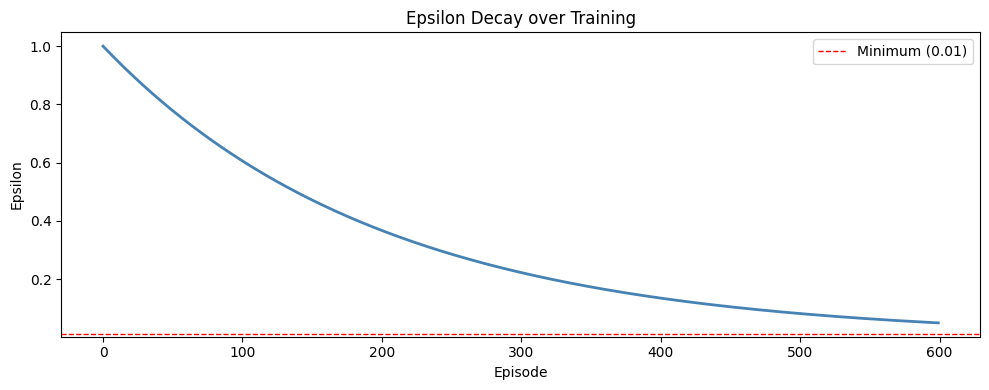

Episode   1: epsilon = 1.000  → 100% random actions
Episode 100: epsilon = 0.609  → 61% random actions
Episode 300: epsilon = 0.223  → 22% random actions
Episode 500: epsilon = 0.082  → 8% random actions


In [12]:
# Simulate epsilon decay over 600 episodes
eps = 1.0
eps_min = 0.01
eps_decay = 0.995
epsilons = []

for ep in range(600):
    epsilons.append(eps)
    eps = max(eps_min, eps * eps_decay)

plt.figure(figsize=(10, 4))
plt.plot(epsilons, color='steelblue', linewidth=2)
plt.axhline(y=eps_min, color='red', linestyle='--', linewidth=1, label=f'Minimum ({eps_min})')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay over Training')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Episode   1: epsilon = {epsilons[0]:.3f}  → {epsilons[0]*100:.0f}% random actions')
print(f'Episode 100: epsilon = {epsilons[99]:.3f}  → {epsilons[99]*100:.0f}% random actions')
print(f'Episode 300: epsilon = {epsilons[299]:.3f}  → {epsilons[299]*100:.0f}% random actions')
print(f'Episode 500: epsilon = {epsilons[499]:.3f}  → {epsilons[499]*100:.0f}% random actions')

### The Bellman Equation — one learning step dissected

The core of DQN training: compute current Q-values, compute target Q-values, minimize their difference.

In [13]:
# Fill the agent's buffer with enough experiences to learn
state, _ = env.reset()
state = np.array(state, dtype=np.float32)

for _ in range(200):
    action = int(env.action_space.sample())
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    agent.memory.push(state, action, float(reward), np.array(next_state, dtype=np.float32), done)
    state = np.array(next_state, dtype=np.float32)
    if done:
        state, _ = env.reset()
        state = np.array(state, dtype=np.float32)

# Sample a batch manually to inspect the computation
states, actions, rewards_b, next_states, dones_b = agent.memory.sample(agent.batch_size)

# Current Q-values: what the online network currently predicts
actions_l = actions.long()
current_q = agent.online_net(states).gather(1, actions_l.unsqueeze(1)).squeeze(1)

# Target Q-values: what the network should predict (Bellman equation)
with torch.no_grad():
    max_next_q = agent.target_net(next_states).max(dim=1).values
    target_q   = rewards_b + agent.gamma * max_next_q * (1 - dones_b)

import torch.nn as nn
loss = nn.MSELoss()(current_q, target_q)

print('=== One Learning Step ===')
print(f'current_q (first 5) : {current_q[:5].detach().tolist()}')
print(f'target_q  (first 5) : {target_q[:5].tolist()}')
print(f'MSE Loss            : {loss.item():.4f}')
print()
print('The optimizer will update the online network weights to reduce this loss.')

=== One Learning Step ===
current_q (first 5) : [-0.02241375297307968, -0.08486206829547882, 0.13751612603664398, -0.041675012558698654, -0.01769860088825226]
target_q  (first 5) : [1.151132583618164, 1.190922737121582, 1.1296923160552979, 1.156099557876587, 1.1388355493545532]
MSE Loss            : 1.2688

The optimizer will update the online network weights to reduce this loss.


---
## 5. Training Curve

After running `train.py`, a training curve is saved in `results/training_curve.png`.
Let's reload and inspect it here.

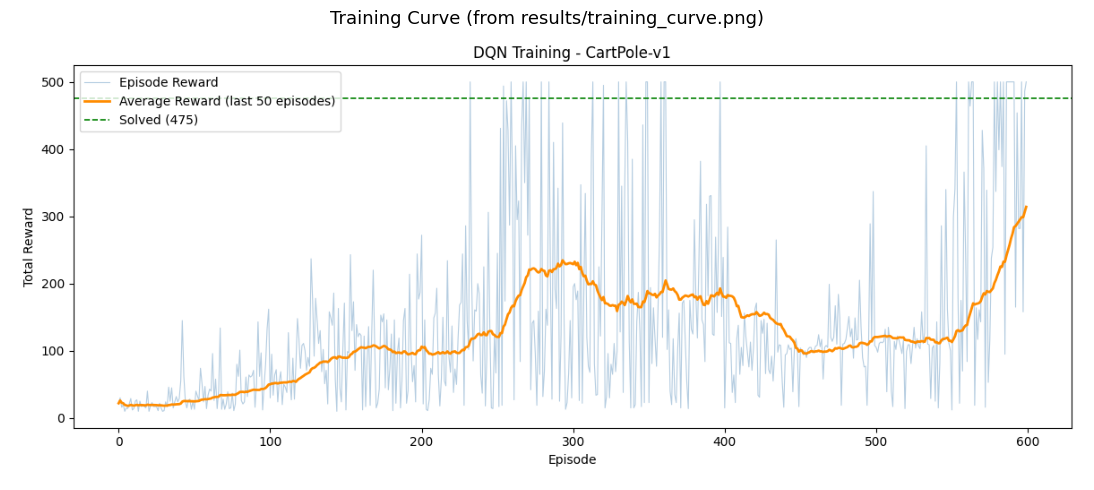

In [15]:
import os
from PIL import Image

plot_path = os.path.join('..', 'results', 'training_curve.png')

if os.path.exists(plot_path):
    img = Image.open(plot_path)
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Curve (from results/training_curve.png)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Training curve not found. Run train.py first, then come back here!')

---
## 6. Watch the Trained Agent Play

Load the saved model weights and run a few episodes to see how the trained agent performs.

> ⚠️ This cell requires the model to be trained first (`python train.py` in `src/`).

In [19]:
import os

# Build the path relative to this notebook's location — works regardless of
# where Jupyter was launched from
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('exploration.ipynb'))
MODEL_PATH   = os.path.join(NOTEBOOK_DIR, '..', 'results', 'dqn-cartpole.pth')
N_EVAL_EPISODES = 5

# Debug: print the resolved path so we can verify it
print(f'Looking for model at: {os.path.abspath(MODEL_PATH)}')

if not os.path.exists(MODEL_PATH):
    print('Model not found. Run train.py first!')
else:
    # Load the trained agent (epsilon=0 → pure exploitation, no random actions)
    trained_agent = DQNAgent(state_size=4, action_size=2, epsilon=0.0)
    trained_agent.load(MODEL_PATH)

    eval_env = gym.make('CartPole-v1')
    episode_rewards = []

    for ep in range(1, N_EVAL_EPISODES + 1):
        state, _ = eval_env.reset()
        state = np.array(state, dtype=np.float32)
        total_reward: float = 0.0

        for _ in range(500):
            action = trained_agent.select_action(state, eval_env)
            next_state, reward, terminated, truncated, _ = eval_env.step(action)
            total_reward += float(reward)
            state = np.array(next_state, dtype=np.float32)
            if terminated or truncated:
                break

        episode_rewards.append(total_reward)
        print(f'Episode {ep}: reward = {total_reward:.0f}')

    eval_env.close()
    print()
    print(f'Average reward over {N_EVAL_EPISODES} episodes: {np.mean(episode_rewards):.1f}')
    print(f'CartPole is considered solved at avg reward >= 475')

Looking for model at: /mnt/c/Users/ricca/Desktop/dqn-cartpole/results/dqn-cartpole.pth
Training on: cpu
Model loaded from /mnt/c/Users/ricca/Desktop/dqn-cartpole/notebooks/../results/dqn-cartpole.pth
Episode 1: reward = 308
Episode 2: reward = 293
Episode 3: reward = 302
Episode 4: reward = 304
Episode 5: reward = 318

Average reward over 5 episodes: 305.0
CartPole is considered solved at avg reward >= 475


---
## Summary

| Component | File | Role |
|---|---|---|
| Neural network | `model.py` | Maps state → Q-values |
| Replay buffer | `replay_buffer.py` | Stores and samples experiences |
| Agent | `agent.py` | Epsilon-greedy selection + Bellman learning |
| Training loop | `train.py` | Runs episodes, saves model and plot |

**Key concepts implemented:**
- **Experience Replay**: random batch sampling breaks temporal correlations
- **Target Network**: a frozen copy of the network provides stable training targets
- **Epsilon-Greedy**: balances exploration and exploitation over time
- **Bellman Equation**: `Q_target = r + γ · max(Q(s')) · (1 - done)`